# Machine Learning básico aplicado a la Gestión Energética

### De los datos al modelo: cómo hacer que Python "aprenda" patrones útiles

---

## Antes de empezar:

Como en la clase de EDA, aquí **no memorizamos código**. El objetivo es que entiendan, con un caso real de gestión energética, **qué es machine learning, para qué sirve, cuándo usarlo y cómo saber si un modelo es confiable**.

Vamos a retomar exactamente el mismo caso de la clase anterior: la instalación con 90 días de mediciones horarias de energía, demanda, temperatura, producción y ocupación.

## La idea central, en una frase

> **Machine learning es la diferencia entre programar reglas explícitas ("si la temperatura supera 30°C, sube el consumo 5%") y darle ejemplos a un algoritmo para que él mismo descubra esa regla a partir de los datos.**

Con esos ejemplos, un modelo puede:

- **Predecir** lo que va a pasar (¿cuánta energía se va a consumir la próxima hora?).
- **Clasificar** situaciones nuevas (¿esta hora se parece a una hora de alto riesgo de pico?).
- **Agrupar** patrones que no sabíamos que existían (¿hay "tipos" de días de operación que no habíamos identificado?).

## Resultados de aprendizaje

Al terminar esta clase vas a poder:

- Explicar la diferencia entre **aprendizaje supervisado** y **no supervisado**, con ejemplos propios de energía.
- Entender qué significa **entrenar** un modelo, **probarlo** con datos que nunca vio, y por qué eso es innegociable.
- Leer un gráfico de **error de predicción** y saber si un modelo es útil o no.
- Interpretar qué variables **pesan más** en una predicción (importancia de variables).
- Formular **prompts precisos** para pedirle a una IA que construya un modelo, y **validar** lo que te entrega en vez de copiarlo a ciegas.

## Bloque 1 · ¿Qué es machine learning, en serio?

Olvidemos por un momento la palabra "inteligencia artificial" y pensemos en algo mucho más simple: **ajustar una curva a unos puntos**.

Imaginen que tienen, para cada día, dos números: la temperatura promedio y la energía consumida ese día. Si los grafican, probablemente vean que a mayor temperatura, mayor consumo (por el aire acondicionado, por ejemplo). Un ser humano, mirando esa nube de puntos, podría trazar a ojo una línea que pase "por la mitad" de los puntos. **Eso, literalmente, es lo que hace un modelo de machine learning**: encuentra, de forma automática y matemáticamente óptima, la función que mejor describe la relación entre unas variables (temperatura, producción, hora del día) y otra que nos interesa predecir (energía consumida).

La diferencia frente a "programar reglas" es esta:

| Enfoque tradicional (reglas) | Machine learning |
|---|---|
| Un humano escribe: "si hora entre 7 y 18 y producción > 50, entonces energía ≈ X" | El algoritmo **descubre** esa relación mirando miles de ejemplos históricos |
| Frágil ante casos nuevos o combinaciones no previstas | Generaliza mejor a situaciones parecidas, no idénticas |
| Requiere que el experto conozca **todas** las reglas de antemano | Requiere **datos históricos representativos**, no necesariamente todas las reglas explícitas |

### Los tres tipos de problema que vamos a ver hoy

1. **Regresión** (aprendizaje supervisado): predecir un **número**. Ejemplo: ¿cuántos kWh se van a consumir la próxima hora?
2. **Clasificación** (aprendizaje supervisado): predecir una **categoría**. Ejemplo: ¿esta hora es "de alto riesgo de pico" sí o no?
3. **Clustering** (aprendizaje **no** supervisado): **agrupar** datos parecidos sin decirle al modelo de antemano cuáles son los grupos. Ejemplo: ¿existen "tipos de día" de operación que no habíamos identificado a simple vista?

Se llama "supervisado" cuando le damos al modelo la respuesta correcta durante el entrenamiento (le decimos "este día consumió tanto"), y "no supervisado" cuando no le damos ninguna respuesta y dejamos que encuentre estructura por sí mismo.

### La regla de oro que nunca deben olvidar

> **Un modelo se entrena con una parte de los datos, y se evalúa con otra parte que nunca vio durante el entrenamiento.**

¿Por qué? Porque si evaluamos un modelo con los mismos datos con los que aprendió, es como calificar un examen dejando que el estudiante lo responda con las respuestas ya escritas al lado: **siempre** va a salir perfecto, pero eso no nos dice nada sobre si de verdad aprendió algo útil para situaciones nuevas. A este problema se le llama **sobreajuste** (*overfitting*): un modelo que "memorizó" los datos de entrenamiento en vez de aprender el patrón general, y que por eso falla con datos nuevos.

## Bloque 2 · Preparar los datos para un modelo

Vamos a reconstruir el mismo caso de la clase de EDA: 90 días de datos horarios de una instalación, con energía, demanda, temperatura, producción, ocupación y horario. No vamos a repetir la auditoría y limpieza completa (ya la hicimos a fondo la clase pasada); la siguiente celda genera directamente una versión ya lista, con las mismas variables de tiempo que construimos entonces, para que hoy nos concentremos en la parte nueva: el modelado.

Esta celda **sí viene resuelta** (no es una práctica de Copilot), porque construir el caso de estudio no es un concepto de machine learning — es solo el punto de partida común para toda la clase. Ejecútenla y sigan adelante.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid")

fechas = pd.date_range("2026-01-01", periods=90*24, freq="h")
df = pd.DataFrame({"fecha_hora": fechas})
df["hora"] = df["fecha_hora"].dt.hour
df["dia_num"] = df["fecha_hora"].dt.dayofweek
df["dia_semana"] = df.dia_num.map({0:"Lunes",1:"Martes",2:"Miércoles",3:"Jueves",4:"Viernes",5:"Sábado",6:"Domingo"})
es_laboral = df["dia_num"] < 5
en_operacion = es_laboral & df["hora"].between(7, 18)
df["es_laboral"] = es_laboral
df["en_horario"] = en_operacion

df["temperatura_c"] = 18 + 5*np.sin(2*np.pi*(df["hora"]-8)/24) + np.random.normal(0,1.5,len(df))
df["produccion_unidades"] = np.clip(np.where(en_operacion, np.random.normal(80,15,len(df)),0),0,None).round()
df["ocupacion"] = np.where(en_operacion, np.random.randint(35,81,len(df)), np.random.randint(0,6,len(df)))
df["energia_kwh"] = np.clip(
    22 + 0.38*df["produccion_unidades"]
    + 1.8*np.maximum(df["temperatura_c"]-20,0)
    + np.random.normal(0,3,len(df)), 5, None)
df["demanda_kw"] = df["energia_kwh"]*np.random.uniform(0.92,1.12,len(df))
df["tarifa"] = np.select([df["hora"].between(18,21),df["hora"].between(7,17)], ["Punta","Media"], default="Valle")

df = df.set_index("fecha_hora")
df

,hora,dia_num,dia_semana,es_laboral,en_horario,temperatura_c,produccion_unidades,ocupacion,energia_kwh,demanda_kw,tarifa
fecha_hora,,,,,,,,,,,
2026-01-01 00:00:00,0,3,Jueves,True,False,14.41,0.00,5,22.37,22.68,Valle
2026-01-01 01:00:00,1,3,Jueves,True,False,12.96,0.00,2,19.93,19.18,Valle
2026-01-01 02:00:00,2,3,Jueves,True,False,13.97,0.00,4,17.97,18.46,Valle
2026-01-01 03:00:00,3,3,Jueves,True,False,15.45,0.00,0,19.45,21.62,Valle
2026-01-01 04:00:00,4,3,Jueves,True,False,13.32,0.00,5,20.49,21.26,Valle
...,...,...,...,...,...,...,...,...,...,...,...
2026-03-31 19:00:00,19,1,Martes,True,False,18.37,0.00,2,22.72,21.45,Punta
2026-03-31 20:00:00,20,1,Martes,True,False,17.44,0.00,2,24.23,23.62,Punta
2026-03-31 21:00:00,21,1,Martes,True,False,16.23,0.00,3,25.18,25.73,Punta


Los modelos que vamos a usar **solo entienden números**, no texto. Por eso la variable `tarifa` (hoy es texto: "Valle", "Media", "Punta") hay que convertirla en columnas de 0 y 1 — una técnica llamada **codificación** (*one-hot encoding*). No necesitan entender el detalle técnico; solo que es un paso obligatorio de "traducción" antes de que cualquier modelo pueda usar una variable de categorías. Este es nuestro primer ejercicio en vivo con Copilot.

---

### 🤖 Práctica con Copilot #1 — Codificar la variable de tarifa

**Prompt sugerido:**

> Tengo un DataFrame de pandas llamado `df`, con una fila por hora, que incluye una columna de texto llamada `tarifa` con tres valores posibles: "Valle", "Media", "Punta". Escribe código que cree una nueva variable llamada `df_modelo`, copiando `df` y agregando una columna binaria (0 o 1) por cada valor de `tarifa`, con el prefijo `tarifa_` en el nombre de cada columna nueva. Al final, muestra con el set de datos solo estas columnas: `hora`, `dia_num`, `temperatura_c`, `produccion_unidades`, `ocupacion`, `es_laboral`, `tarifa_Valle`, `tarifa_Media`, `tarifa_Punta`.

**Cómo validar lo que Copilot devuelva:**

1. ¿El resultado tiene tres columnas nuevas (`tarifa_Valle`, `tarifa_Media`, `tarifa_Punta`), y ya no aparece la columna de texto `tarifa` original?
2. En cada fila, ¿hay exactamente un **1** entre esas tres columnas nuevas, y **0** en las otras dos? (Cada hora solo puede estar en un periodo tarifario a la vez.)
3. ¿El código usa el nombre exacto `df_modelo` para guardar el resultado? Lo vamos a necesitar así en los siguientes pasos.

In [3]:
df_modelo = df.copy()
df_modelo = pd.get_dummies(df_modelo, columns=["tarifa"], prefix="tarifa")

# Asegurar que las columnas one-hot queden como enteros (0/1)
for col in ["tarifa_Valle", "tarifa_Media", "tarifa_Punta"]:
    df_modelo[col] = df_modelo[col].astype(int)

columnas_mostrar = [
    "hora", "dia_num", "temperatura_c", "produccion_unidades", "ocupacion",
    "es_laboral", "tarifa_Valle", "tarifa_Media", "tarifa_Punta",
]
df_modelo[columnas_mostrar]

,hora,dia_num,temperatura_c,produccion_unidades,ocupacion,es_laboral,tarifa_Valle,tarifa_Media,tarifa_Punta
fecha_hora,,,,,,,,,
2026-01-01 00:00:00,0,3,14.41,0.00,5,True,1,0,0
2026-01-01 01:00:00,1,3,12.96,0.00,2,True,1,0,0
2026-01-01 02:00:00,2,3,13.97,0.00,4,True,1,0,0
2026-01-01 03:00:00,3,3,15.45,0.00,0,True,1,0,0
2026-01-01 04:00:00,4,3,13.32,0.00,5,True,1,0,0
...,...,...,...,...,...,...,...,...,...
2026-03-31 19:00:00,19,1,18.37,0.00,2,True,0,0,1
2026-03-31 20:00:00,20,1,17.44,0.00,2,True,0,0,1
2026-03-31 21:00:00,21,1,16.23,0.00,3,True,0,0,1


## Bloque 3 · Regresión: predecir cuánta energía se va a consumir

Este es el tipo de modelo más común en gestión energética: dado el contexto (hora, temperatura, producción esperada), **predecir el consumo antes de que ocurra**. Esto es lo que hace posible, por ejemplo, anticipar la demanda del día siguiente para negociar mejor un contrato de energía, o programar el uso de baterías o generación propia.

### Paso 1 — Separar entrenamiento y prueba

Vamos a dividir nuestros datos en dos partes:

- **Entrenamiento (train):** el 80 % de las horas, con las que el modelo va a "aprender" la relación entre las variables y el consumo.
- **Prueba (test):** el 20 % restante, que el modelo **nunca ve durante el entrenamiento**, y que usamos únicamente para evaluar qué tan bien predice en situaciones nuevas.

Como nuestros datos son una serie de tiempo (una hora sigue a la otra), la forma correcta de dividir no es aleatoria, sino **cronológica**: entrenamos con el pasado y probamos con el futuro más reciente. Esto imita el escenario real: en la práctica, uno siempre predice el futuro con datos del pasado, nunca al revés.

---

### 🤖 Práctica con Copilot #2 — Dividir en entrenamiento y prueba

**Prompt sugerido:**

> Tengo un DataFrame `df_modelo` indexado por fecha y hora, ordenado cronológicamente, con una columna numérica objetivo llamada `energia_kwh`. Quiero usar como variables de entrada (features) exactamente estas columnas: `hora`, `dia_num`, `temperatura_c`, `produccion_unidades`, `ocupacion`, `es_laboral`, `tarifa_Valle`, `tarifa_Media`, `tarifa_Punta`. Escribe código en Python que: 1) guarde esa lista de columnas en una variable llamada `features`, 2) divida `df_modelo` cronológicamente en 80% para entrenamiento y 20% para prueba (no mezcles los datos y dejalos en orden cronológico, ya que este set de datos depende de la conología), 3) construya la entrada y salida de entrenamiento y de test a partir de `features` y `energia_kwh`, y 4) imprima cuántas horas quedaron en cada conjunto y las fechas mínima y máxima de cada uno.

**Cómo validar lo que Copilot devuelva:**

1. ¿El conjunto de prueba corresponde a las fechas **más recientes**, y el de entrenamiento a las más antiguas (no al revés, y no mezclado al azar)?
2. ¿La suma de horas de `train` y `test` da el total de filas de `df_modelo`?
3. ¿Los nombres de las variables son exactamente `features`, `X_train`, `y_train`, `X_test`, `y_test`? Los vamos a reutilizar en el siguiente paso.

In [4]:
features = [
    "hora", "dia_num", "temperatura_c", "produccion_unidades", "ocupacion",
    "es_laboral", "tarifa_Valle", "tarifa_Media", "tarifa_Punta",
]

corte = int(len(df_modelo) * 0.8)
train = df_modelo.iloc[:corte]
test = df_modelo.iloc[corte:]

X_train, y_train = train[features], train["energia_kwh"]
X_test, y_test = test[features], test["energia_kwh"]

print(f"Entrenamiento: {len(train)} horas, de {train.index.min()} a {train.index.max()}")
print(f"Prueba: {len(test)} horas, de {test.index.min()} a {test.index.max()}")

Entrenamiento: 1728 horas, de 2026-01-01 00:00:00 a 2026-03-13 23:00:00
Prueba: 432 horas, de 2026-03-14 00:00:00 a 2026-03-31 23:00:00


### Paso 2 — Entrenar dos modelos distintos y comparar

Vamos a probar dos algoritmos de regresión muy distintos entre sí, para que vean que "machine learning" no es un solo método, sino una familia de técnicas con distintas fortalezas:

- **Regresión lineal:** el más simple. Busca la mejor línea (o plano, con varias variables) que relaciona las variables de entrada con la energía. Es fácil de interpretar, pero asume relaciones simples.
- **Bosque aleatorio (Random Forest):** un modelo más flexible, que combina cientos de "árboles de decisión" internos. Puede capturar relaciones más complejas (como que el efecto de la temperatura cambie según la hora del día), a costa de ser más difícil de interpretar directamente.

Con `scikit-learn` (la librería estándar de la industria para este tipo de modelos en Python), el patrón siempre es el mismo, sin importar el algoritmo: **crear el modelo → entrenarlo (`.fit`) → predecir (`.predict`)**.

---

### 🤖 Práctica con Copilot #3 — Entrenar y comparar dos modelos de regresión

**Prompt sugerido:**

> Ya tengo mi set de entrenamiento y prueba definidos (todos numéricos, sin valores faltantes). Escribe código en Python usando que: 1) entrene una regresión lineal, 2) entrene un Random Forest con los parámetros más adecuados, 3) genere predicciones de ambos modelos sobre el set de prueba, 4) calcule para cada modelo el error y cuál es más preciso, y 5) muestre los resultados en una tabla con columnas `modelo` y métricas de error. Guarda las predicciones del bosque aleatorio en una variable llamada `pred_bosque`, porque la voy a graficar después.

**Cómo validar lo que Copilot devuelva:**

1. ¿Entrena ambos modelos **solo** con `X_train`/`y_train`, y evalúa **solo** con `X_test`/`y_test`? (Si evalúa con los datos de entrenamiento, el resultado va a parecer mejor de lo que realmente es — el error de sobreajuste que discutimos en el Bloque 1.)
2. ¿El error promedio está en la misma unidad que `energia_kwh` (kWh), y es un número razonable — pocas unidades, no cientos?
3. ¿El R² está entre 0 y 1 (valores cercanos a 1 indican mejor ajuste)? Comparen cuál de los dos modelos obtuvo mejor resultado, y discutan por qué podría ser.

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

modelo_lineal = LinearRegression()
modelo_lineal.fit(X_train, y_train)
pred_lineal = modelo_lineal.predict(X_test)

modelo_bosque = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42)
modelo_bosque.fit(X_train, y_train)
pred_bosque = modelo_bosque.predict(X_test)

resultados = pd.DataFrame({
    "modelo": ["Regresión lineal", "Random Forest"],
    "error_promedio_kwh": [
        mean_absolute_error(y_test, pred_lineal),
        mean_absolute_error(y_test, pred_bosque),
    ],
    "r2_test": [
        r2_score(y_test, pred_lineal),
        r2_score(y_test, pred_bosque),
    ],
})
resultados

,modelo,error_promedio_kwh,r2_test
0,Regresión lineal,2.78,0.95
1,Random Forest,2.61,0.96


### Cómo leer estos dos números

- **Error promedio (MAE, "Mean Absolute Error"):** en promedio, cuántos kWh se equivoca el modelo por hora, sin importar si se equivocó por arriba o por abajo. Está en las mismas unidades que la energía, así que es directamente interpretable: "en promedio nos equivocamos en X kWh por hora".
- **R² (coeficiente de determinación):** un número entre 0 y 1 (a veces puede salir negativo si el modelo es muy malo) que mide qué proporción de la variabilidad del consumo logra explicar el modelo. Un R² de 0.90 significa que el modelo explica el 90 % de los cambios en el consumo; el 10 % restante queda como algo que el modelo no logra capturar (ruido, variables que no medimos, etc.).

Ningún modelo va a tener R² de 1.0 ni error de 0 con datos reales — y **eso está bien**. La pregunta correcta no es "¿es perfecto?", sino "¿es suficientemente bueno para la decisión que quiero tomar con él?".

---

### 🤖 Práctica con Copilot #4 — Visualizar predicción vs. realidad

**Prompt sugerido:**

> Tengo el DataFrame de prueba, indexado por fecha y hora, y la energía predicha por el bosque aleatorio. Escribe código en Python que grafique ambas series sobre el mismo eje de tiempo, con una línea para "Real" y otra para "Predicho", con leyenda, título y la etiqueta del eje Y en kWh.

**Cómo validar lo que Copilot devuelva:**

1. ¿Las dos líneas siguen, a grandes rasgos, la misma forma general (suben y bajan juntas)? Si están completamente desconectadas, algo salió mal en un paso anterior.
2. ¿Hay tramos donde el modelo se aleja más de lo normal? Miren si coinciden con horas de consumo inusualmente alto (¿les recuerda a las anomalías de la clase pasada?).
3. ¿El eje X muestra fechas legibles y el eje Y está en las unidades correctas (kWh)?

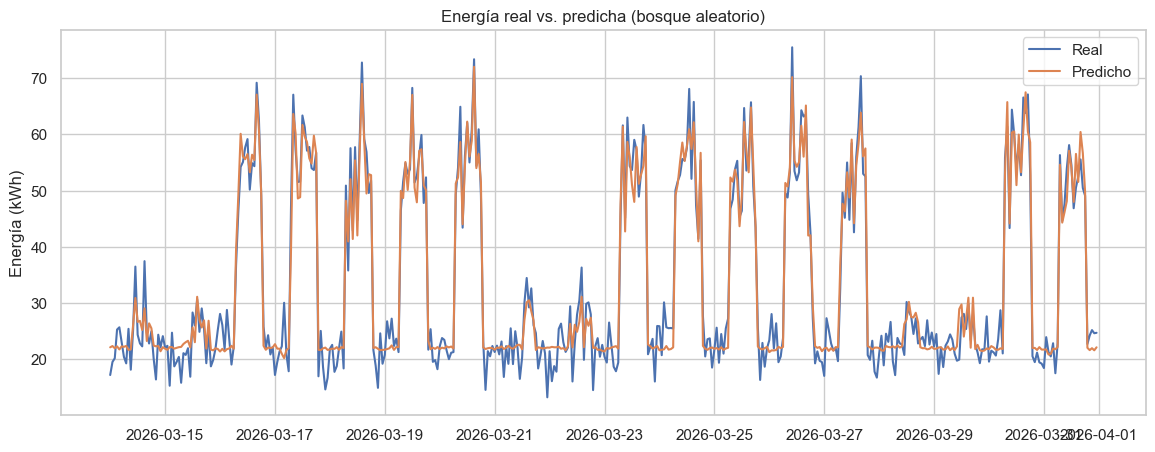

In [6]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test.index, y_test, label="Real")
ax.plot(test.index, pred_bosque, label="Predicho")
ax.set_title("Energía real vs. predicha (bosque aleatorio)")
ax.set_ylabel("Energía (kWh)")
ax.legend()
plt.show()

### ¿Qué variables usó más el modelo? — Importancia de variables

El bosque aleatorio nos puede decir, de forma directa, **qué tanto peso le dio a cada variable** para hacer sus predicciones. Esto es sumamente útil en gestión energética: no solo obtenemos una predicción, sino una pista de **qué es lo que realmente mueve el consumo** en esta instalación, según lo que el modelo aprendió de los datos.

---

### 🤖 Práctica con Copilot #5 — Importancia de variables

**Prompt sugerido:**

> Tengo un modelo que acabé de ejecutar de bosque aleatorio ya entrenado, y una lista `features` con los nombres de las columnas usadas como entrada, en el mismo orden en que se entrenó el modelo. Escribe código en Python que me diga cual es la importancia de cada variable de entrada dentro del modelo entrenado y grafique un gráfico de barras horizontal con esa información, con título y con la variable más importante arriba.

**Cómo validar lo que Copilot devuelva:**

1. ¿El nombre del modelo que usó en el código coincide exactamente con el que ustedes usaron al entrenar en la Práctica #3? (Si no coincide, ajústenlo antes de ejecutar.)
2. ¿Las variables con más peso son, más o menos, las que ya sospechaban desde la clase de EDA (recuerden la matriz de correlación de esa clase)?
3. ¿La suma de todas las importancias da, aproximadamente, 1? (Es una propiedad matemática de este método; si no se cumple, algo está mal calculado.)

**Discusión de clase:** si `produccion_unidades` y `temperatura_c` resultan ser las variables más importantes, eso **confirma cuantitativamente** algo que ya veníamos sospechando. Esto es justamente lo valioso de machine learning aplicado con criterio: no reemplaza el análisis exploratorio, **lo confirma y lo extiende** con una herramienta capaz de predecir, no solo describir.

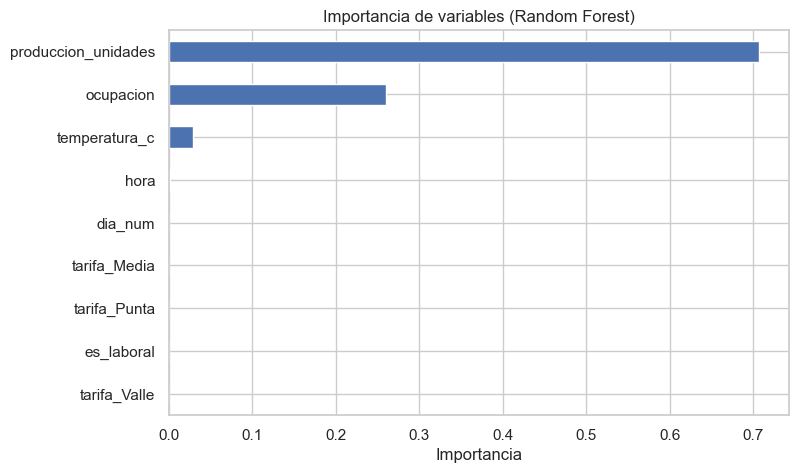

In [7]:
importancias = pd.Series(modelo_bosque.feature_importances_, index=features).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
importancias.plot(kind="barh", ax=ax)
ax.set_title("Importancia de variables (Random Forest)")
ax.set_xlabel("Importancia")
plt.show()

## Bloque 4 · Clasificación: predecir si una hora es de "alto riesgo"

Ahora cambiemos el tipo de pregunta. En vez de predecir un número exacto de kWh, queremos predecir una **categoría**: ¿esta hora tiene alto riesgo de ser un pico de demanda costoso, sí o no? Este tipo de modelo es la base de sistemas de **alerta temprana**: en vez de esperar a que ocurra el pico y verlo en la factura, el modelo avisa con anticipación.

Vamos a definir "alto riesgo" como: la demanda de esa hora está en el **20 % más alto** de todo el periodo. Es una definición simple a propósito, para que puedan replicar la lógica con cualquier otro umbral que tenga sentido para su propio caso de negocio.

---

### 🤖 Práctica con Copilot #6 — Definir la etiqueta de "alto riesgo"

**Prompt sugerido:**

> Tengo un DataFrame `df_modelo` con una columna numérica `demanda_kw`. Escribe código que calcule el percentil 80 de `demanda_kw` y lo guarde en una variable `umbral_riesgo`. Luego crea una nueva columna en `df_modelo` llamada `alto_riesgo`, con valor 1 si `demanda_kw` es mayor o igual al umbral, y 0 en caso contrario (como número entero, no booleano). Al final, imprime el valor de `umbral_riesgo` y la proporción de horas en cada categoría (0 y 1).

**Cómo validar lo que Copilot devuelva:**

1. ¿La proporción de horas en la categoría 1 (alto riesgo) es, aproximadamente, el 20 % del total? (Es justamente lo que define un percentil 80.)
2. ¿La columna `alto_riesgo` solo contiene los valores 0 y 1, sin datos faltantes?
3. ¿El umbral impreso tiene sentido físico (un número de kW razonable, ni negativo ni absurdamente alto)?

In [8]:
umbral_riesgo = df_modelo["demanda_kw"].quantile(0.8)
df_modelo["alto_riesgo"] = (df_modelo["demanda_kw"] >= umbral_riesgo).astype(int)

print(f"Umbral de riesgo: {umbral_riesgo:.2f} kW")
print(df_modelo["alto_riesgo"].value_counts(normalize=True))

Umbral de riesgo: 54.15 kW
alto_riesgo
0   0.80
1   0.20
Name: proportion, dtype: float64


Ahora entrenamos un modelo de **clasificación**. Vamos a usar **regresión logística**, uno de los algoritmos de clasificación más usados y más fáciles de interpretar: en vez de predecir un número cualquiera, predice una **probabilidad** entre 0 y 1 de que la hora pertenezca a la categoría "alto riesgo".

---

### 🤖 Práctica con Copilot #7 — Entrenar el clasificador y leer sus resultados

**Prompt sugerido:**

> Tengo un DataFrame `df_modelo` ordenado cronológicamente, con una lista `features` de columnas de entrada (las mismas que usé para el modelo de predicción) y una columna objetivo `alto_riesgo` (valores 0 o 1). Escribe código en Python que: 1) divida `df_modelo` cronológicamente en 80% entrenamiento y 20% prueba (igual que hicimos para el modelo de predicción, no aleatorio), 2) entrene un modelo de clasificación apropiado para estos datos, guardado en una variable `modelo_clasif`, 3) genere predicciones sobre el set de prueba guardadas en `pred_clasif`, y 4) imprima un reporte comparando datos reales y la clasificación realizada por el modelo, usando como nombres de clase "Riesgo normal" y "Alto riesgo".

**Cómo validar lo que Copilot devuelva:**

1. ¿Usó una división **cronológica**, igual que en la regresión, y no una división aleatoria? (Recuerden: es una serie de tiempo.)
2. En el reporte, busquen tres números por clase: **precisión**, **exhaustividad (recall)** y **f1-score**. ¿Estos números están entre 0 y 1?
3. ¿El modelo predice **ambas** categorías al menos alguna vez, o predijo todo como "riesgo normal"? (Si predice solo una clase todo el tiempo, el modelo no está aprendiendo nada útil, y hay que revisar el paso anterior.)

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

corte = int(len(df_modelo) * 0.8)
train = df_modelo.iloc[:corte]
test = df_modelo.iloc[corte:]

X_train, y_train = train[features], train["alto_riesgo"]
X_test, y_test = test[features], test["alto_riesgo"]

modelo_clasif = LogisticRegression(max_iter=1000, class_weight="balanced")
modelo_clasif.fit(X_train, y_train)
pred_clasif = modelo_clasif.predict(X_test)

print(classification_report(y_test, pred_clasif, target_names=["Riesgo normal", "Alto riesgo"]))

# Desglose en cifras absolutas, más fácil de leer que el reporte de arriba
tn, fp, fn, tp = confusion_matrix(y_test, pred_clasif).ravel()
total_alto_riesgo_real = tp + fn
total_riesgo_normal_real = tn + fp

print("--- En palabras simples ---")
print(f"Horas de prueba: {len(y_test)}")
print(f"De las {total_alto_riesgo_real} horas que SÍ eran de alto riesgo, el modelo detectó {tp} ({tp/total_alto_riesgo_real:.0%}) y dejó pasar {fn} ({fn/total_alto_riesgo_real:.0%}).")
print(f"De las {total_riesgo_normal_real} horas de riesgo normal, el modelo dio {fp} falsas alarmas ({fp/total_riesgo_normal_real:.0%}).")

               precision    recall  f1-score   support

Riesgo normal       0.99      0.89      0.94       356
  Alto riesgo       0.66      0.97      0.79        76

     accuracy                           0.91       432
    macro avg       0.83      0.93      0.86       432
 weighted avg       0.94      0.91      0.91       432

--- En palabras simples ---
Horas de prueba: 432
De las 76 horas que SÍ eran de alto riesgo, el modelo detectó 74 (97%) y dejó pasar 2 (3%).
De las 356 horas de riesgo normal, el modelo dio 38 falsas alarmas (11%).


### Cómo leer un reporte de clasificación

Tres métricas aparecen siempre juntas, y cada una responde una pregunta distinta:

- **Precisión (precision):** de todas las horas que el modelo marcó como "alto riesgo", ¿qué porcentaje realmente lo era? Una precisión baja significa muchas **falsas alarmas**.
- **Exhaustividad (recall):** de todas las horas que realmente eran de alto riesgo, ¿qué porcentaje logró detectar el modelo? Una exhaustividad baja significa que el modelo **deja pasar** casos importantes sin avisar.
- **F1-score:** un balance entre las dos anteriores, útil cuando ambos tipos de error importan.

En gestión energética casi siempre hay que decidir conscientemente **cuál error nos duele más**: ¿preferimos algunas falsas alarmas a cambio de no dejar pasar ningún pico real? Esa decisión de negocio no la toma el modelo — la toman ustedes.

---

### 🤖 Práctica con Copilot #8 — Matriz de confusión

**Prompt sugerido:**

> Tengo ya mi clasificación hecha con set de prueba (valores 0 = riesgo normal, 1 = alto riesgo). Escribe código en Python para graficar la matriz de confusión, con las etiquetas "Riesgo normal" y "Alto riesgo", un mapa de color azul y un título.

**Cómo validar lo que Copilot devuelva:**

1. ¿La diagonal principal (arriba-izquierda y abajo-derecha) tiene los números más grandes? Esos son los **aciertos** del modelo.
2. Miren las dos celdas fuera de la diagonal: una son **falsas alarmas** y la otra son **casos no detectados**. ¿Cuál de las dos es más grande en su resultado?
3. Discutan en equipo: en su propio contexto profesional, ¿cuál de esos dos errores les preocuparía más, y por qué?

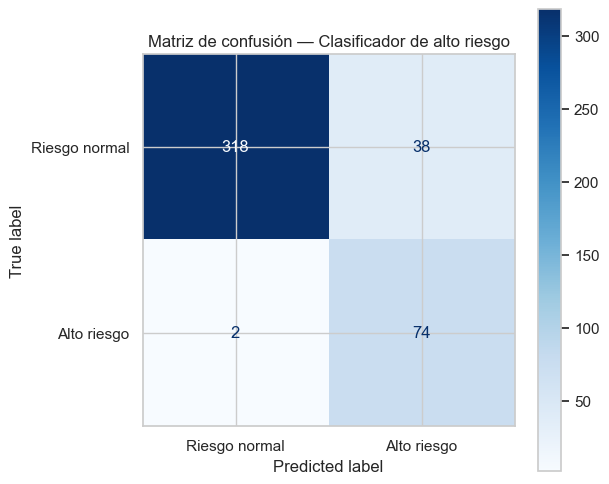

In [11]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, pred_clasif,
    display_labels=["Riesgo normal", "Alto riesgo"],
    cmap="Blues", ax=ax,
)
ax.set_title("Matriz de confusión — Clasificador de alto riesgo")
plt.show()

### 🤖 Práctica con Copilot #9 — Ajustar el umbral de decisión

Los modelos de clasificación como este no solo dan una categoría (0 o 1); por dentro calculan una **probabilidad**, y nosotros decidimos a partir de qué probabilidad decir "sí, alerta". Por defecto suele ser 50 %, pero eso es una elección, no una ley física.

**Prompt sugerido:**

> Tengo un modelo de clasificación que acabó de utilizar ya entrenado, con datos de prueba (0 = riesgo normal, 1 = alto riesgo). Escribe código en Python que obtenga las probabilidades predichas con `predict_proba`, y luego calcule métricas para definir si el modelo es bueno o no, para varios umbrales de decisión distintos (por ejemplo 0.3, 0.4, 0.5, 0.6, 0.7), mostrando los resultados en una tabla. Al final, grafica precisión y exhaustividad contra el umbral en el mismo gráfico, para poder elegir visualmente un buen punto de equilibrio.

**Cómo validar lo que Copilot devuelva:**

1. ¿Usa `predict_proba` correctamente (que devuelve dos columnas: probabilidad de clase 0 y de clase 1) y toma la columna correcta?
2. ¿Al subir el umbral, la precisión sube y la exhaustividad baja (o viceversa)? Esa relación inversa **debe** aparecer siempre — si no aparece, algo está mal planteado.
3. ¿El gráfico permite identificar, a simple vista, en qué umbral está el mejor equilibrio para su caso?

,umbral,precision,exhaustividad
0,0.30,0.63,1.00
1,0.40,0.64,1.00
2,0.50,0.66,0.97
3,0.60,0.69,0.95
4,0.70,0.75,0.91


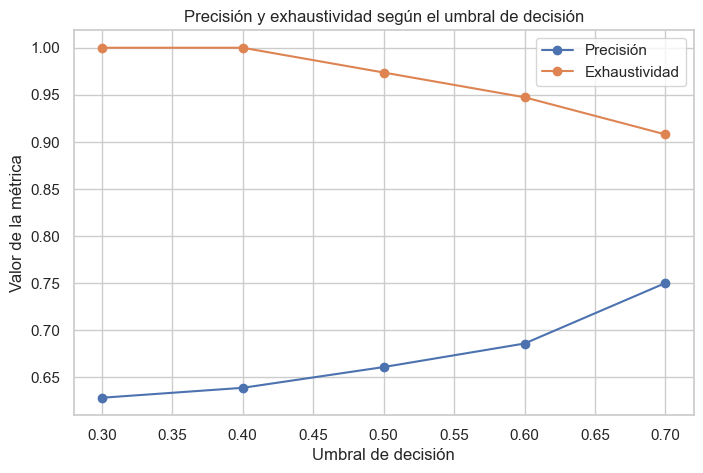

In [12]:
from sklearn.metrics import precision_score, recall_score

probabilidades = modelo_clasif.predict_proba(X_test)[:, 1]
umbrales = [0.3, 0.4, 0.5, 0.6, 0.7]

tabla_umbrales = pd.DataFrame({
    "umbral": umbrales,
    "precision": [precision_score(y_test, probabilidades >= u) for u in umbrales],
    "exhaustividad": [recall_score(y_test, probabilidades >= u) for u in umbrales],
})
display(tabla_umbrales)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(tabla_umbrales["umbral"], tabla_umbrales["precision"], marker="o", label="Precisión")
ax.plot(tabla_umbrales["umbral"], tabla_umbrales["exhaustividad"], marker="o", label="Exhaustividad")
ax.set_xlabel("Umbral de decisión")
ax.set_ylabel("Valor de la métrica")
ax.set_title("Precisión y exhaustividad según el umbral de decisión")
ax.legend()
plt.show()

## Bloque 5 · Clustering: descubrir "tipos de día" sin decirle al modelo cuáles son

Hasta aquí, en ambos modelos, nosotros le dijimos al algoritmo exactamente qué queríamos predecir (energía, o alto riesgo). Ahora vamos a hacer algo distinto: darle al modelo **solo las variables descriptivas de cada día**, sin ninguna "respuesta correcta", y dejar que **él mismo agrupe** los días que se comportan de forma parecida. Esto es aprendizaje **no supervisado**.

¿Para qué sirve esto en gestión energética? Para descubrir **patrones que no sabíamos que existían**. Por ejemplo: puede que existan tres "tipos" de día operativo (alta producción, baja producción, mantenimiento) que nadie había etiquetado formalmente, pero que el consumo de energía revela con claridad si se lo pedimos al algoritmo correcto.

Vamos a resumir cada uno de los 90 días en unas pocas características (energía total, demanda máxima, producción total, temperatura promedio) y a usar el algoritmo **K-Means**, que agrupa los puntos en un número de grupos (*clusters*) que nosotros definimos de antemano.

---

### 🤖 Práctica con Copilot #10 — Resumir cada día y dejarlo listo para agrupar

**Prompt sugerido:**

> Tengo un DataFrame `df` indexado por fecha y hora (una fila por hora), con columnas `energia_kwh`, `demanda_kw`, `produccion_unidades` y `temperatura_c`. Escribe código que agregue los datos por día calendario en un nuevo DataFrame llamado `resumen_diario`, con estas columnas: `energia_total` (suma de `energia_kwh`), `demanda_max` (máximo de `demanda_kw`), `produccion_total` (suma de `produccion_unidades`) y `temperatura_media` (promedio de `temperatura_c`). Luego necesito que me clasifiques con categorías, vamos a generar 3 grupos, en una columna nueva que se llame resumen diario (alta producción, baja producción, mantenimiento) o dime cuales son los mejores clusters o categorías, o que el modelo las clasifique de acuerdo a lo mejor y más apropiado para los datos. Devuelveme tablas y gráficas útiles para ver los clusters de mejor forma y cual es el resultado y que yo lo pueda entender.

**Cómo validar lo que Copilot devuelva:**

1. ¿`resumen_diario` tiene aproximadamente 90 filas (una por día)?
2. ¿Los nombres de columna coinciden exactamente con los que se pidieron?
3. ¿La explicación del escalado menciona que las variables están en escalas distintas (kWh en miles, temperatura en decenas), y que sin escalar, la variable con números más grandes dominaría la distancia entre puntos aunque no sea más importante?

,energia_total,demanda_max,produccion_total,temperatura_media,dias
categoria,,,,,
Alta producción,916.83,71.94,953.48,17.76,25
Baja producción,565.69,34.75,0.00,18.05,26
Mantenimiento,924.14,68.28,945.77,18.24,39


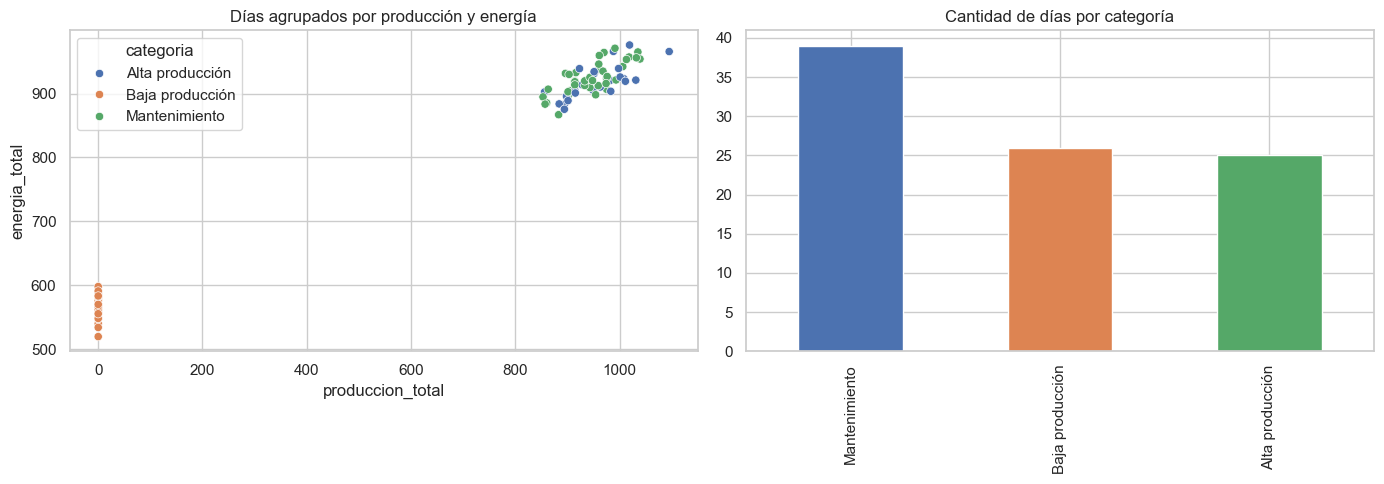

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

resumen_diario = df.resample("D").agg(
    energia_total=("energia_kwh", "sum"),
    demanda_max=("demanda_kw", "max"),
    produccion_total=("produccion_unidades", "sum"),
    temperatura_media=("temperatura_c", "mean"),
)

# Escalamos porque las columnas están en escalas muy distintas (kWh en miles vs. °C en decenas);
# sin esto, la variable con números más grandes dominaría la distancia entre puntos.
columnas_cluster = ["energia_total", "demanda_max", "produccion_total", "temperatura_media"]
X_escalado = StandardScaler().fit_transform(resumen_diario[columnas_cluster])

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
resumen_diario["grupo"] = kmeans.fit_predict(X_escalado)

# Nombramos los grupos según su producción total: el modelo solo entrega números (0,1,2),
# el significado de cada número se lo damos nosotros mirando los promedios.
orden_grupos = resumen_diario.groupby("grupo")["produccion_total"].mean().sort_values().index
nombres = {orden_grupos[0]: "Baja producción", orden_grupos[1]: "Mantenimiento", orden_grupos[2]: "Alta producción"}
resumen_diario["categoria"] = resumen_diario["grupo"].map(nombres)

perfil_grupos = resumen_diario.groupby("categoria")[columnas_cluster].mean()
perfil_grupos["dias"] = resumen_diario["categoria"].value_counts()
display(perfil_grupos)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=resumen_diario, x="produccion_total", y="energia_total", hue="categoria", ax=axes[0])
axes[0].set_title("Días agrupados por producción y energía")

resumen_diario["categoria"].value_counts().plot(kind="bar", ax=axes[1], color=["#4C72B0", "#DD8452", "#55A868"])
axes[1].set_title("Cantidad de días por categoría")
axes[1].set_xlabel("")
plt.tight_layout()
plt.show()

### 🤖 Práctica con Copilot #11 — Agrupar los días con K-Means

**Prompt sugerido:**

> Tengo una matriz `X_escalado` (numpy array ya estandarizado) y un DataFrame `resumen_diario` con las mismas filas en el mismo orden, con columnas `energia_total`, `demanda_max`, `produccion_total`, `temperatura_media`. Escribe código en Python que entrene un `KMeans` de scikit-learn con `n_clusters=3`, `random_state=42` y `n_init=10` sobre `X_escalado`, guarde las etiquetas de grupo asignadas a cada día en una nueva columna `grupo` de `resumen_diario`, y luego construya una tabla con el promedio de `energia_total`, `demanda_max`, `produccion_total` y `temperatura_media` por cada grupo, junto con la cantidad de días que tiene cada grupo.

**Cómo validar lo que Copilot devuelva:**

1. ¿La columna `grupo` solo tiene los valores 0, 1 y 2 (porque pedimos 3 grupos)?
2. ¿La suma de días de los tres grupos da el total de días del `resumen_diario`?
3. ¿Los tres grupos tienen promedios claramente **distintos** entre sí en al menos una de las columnas? (Si todos los grupos tienen valores casi idénticos, el agrupamiento no está aportando información útil.)

In [ ]:
# Pegue aquí el código que le sugiera Copilot para entrenar KMeans y construir la tabla de perfiles por grupo.

### 🤖 Práctica con Copilot #12 — Visualizar los grupos

**Prompt sugerido:**

> Tengo un DataFrame `resumen_diario` con columnas `produccion_total`, `energia_total` y `grupo` (valores 0, 1, 2). Escribe código en Python con matplotlib y seaborn que muestre dos gráficos lado a lado: a la izquierda, un `scatterplot` de `produccion_total` contra `energia_total`, coloreado por `grupo`; a la derecha, un gráfico de barras con la cantidad de días por grupo. Agrega títulos a ambos gráficos.

**Cómo validar lo que Copilot devuelva:**

1. ¿En el gráfico de puntos, los colores forman zonas relativamente separadas, o están todos mezclados sin ningún patrón visible?
2. ¿El gráfico de barras coincide con los conteos de días por grupo que ya vieron en la tabla de la práctica anterior?

### Cómo interpretar los grupos (y por qué esta parte es 100 % humana)

El algoritmo nos entrega **grupos numerados** (0, 1, 2) — no les pone nombre, no sabe qué significan. **Ponerles nombre e interpretarlos es trabajo del analista**, mirando la tabla de promedios por grupo:

- ¿Un grupo tiene alta producción, alta energía y muchos días? Probablemente sean los "días operativos típicos".
- ¿Un grupo tiene baja producción pero energía todavía relativamente alta? Podría señalar **ineficiencia** — consumo que no está acompañado de producción proporcional, justo el tipo de hallazgo que interesa en un estudio de eficiencia energética.
- ¿Un grupo es pequeño y atípico? Podría representar días especiales: paradas de mantenimiento, fines de semana con actividad inusual, etc.

Este ejercicio conecta directamente con la clase anterior: el clustering es, en cierto modo, una versión automatizada y más rigurosa de lo que empezamos a explorar manualmente con el mapa de calor semanal.

In [ ]:
# Pegue aquí el código que le sugiera Copilot para graficar los grupos.

### 🤖 Práctica con Copilot #13 — ¿Cuántos grupos son los correctos?

Elegimos 3 grupos casi arbitrariamente. Pero, ¿cómo se elige ese número de forma más rigurosa? Una técnica común es el **método del codo** (*elbow method*): se prueba el algoritmo con distintas cantidades de grupos y se observa en qué punto agregar más grupos deja de mejorar significativamente el resultado.

**Prompt sugerido:**

> Tengo una matriz `X_escalado` (numpy array, ya estandarizada) con la que voy a aplicar KMeans de scikit-learn. Escribe código en Python que entrene KMeans para un rango de números de grupos de 2 a 8, guarde para cada uno la métrica `inertia_` del modelo, y grafique esa métrica contra el número de grupos (el "método del codo"), para poder elegir visualmente el número de grupos donde la curva deja de bajar de forma pronunciada. Usa `random_state=42` en todos los casos para que el resultado sea reproducible.

**Cómo validar:**

1. ¿La métrica `inertia_` disminuye a medida que aumenta el número de grupos? (Eso siempre debe pasar — más grupos siempre reducen la inercia; el punto es encontrar dónde deja de valer la pena seguir agregando.)
2. ¿El gráfico realmente muestra un "codo" claro, o la decisión sigue siendo algo subjetiva? (Es normal que a veces no haya un codo perfectamente claro — en ese caso, el criterio de negocio, como "necesitamos máximo 4 categorías operativas manejables", puede pesar tanto como la matemática.)
3. Con el número de grupos que sugiere el codo, ¿el resultado sigue siendo interpretable, o termina en grupos demasiado pequeños para ser útiles?

In [ ]:
# Pegue aquí el código sugerido por GitHub Copilot para el método del codo.
# Compare el número de grupos sugerido contra los 3 grupos que usamos en la práctica #11.

## Bloque 6 · Aplicaciones profesionales: qué pueden hacer con esto en su trabajo

Estos tres modelos que acaban de construir no son un ejercicio de laboratorio: son la base técnica de herramientas que se usan hoy en la industria energética. Algunas ideas concretas para llevarse a su vida profesional:

| Lo que hicimos hoy | Aplicación profesional real |
|---|---|
| Regresión de consumo | **Pronóstico de demanda** para negociar contratos de energía, dimensionar baterías o paneles solares, o planear mantenimientos sin afectar producción |
| Clasificación de alto riesgo | **Sistemas de alerta temprana** que avisan antes de un pico de demanda costoso, permitiendo desconectar cargas no críticas a tiempo |
| Clustering de días | **Segmentación operativa** para identificar patrones de ineficiencia, priorizar auditorías energéticas, o diseñar tarifas y contratos diferenciados por tipo de operación |
| Importancia de variables | **Diagnóstico de causas raíz**: saber qué invertir primero para reducir consumo (¿controlar temperatura interna? ¿optimizar producción?) |

Otras aplicaciones de machine learning en el sector energético que vale la pena conocer, aunque no las hayamos construido hoy:

- **Mantenimiento predictivo:** predecir la falla de un equipo *antes* de que ocurra, a partir de patrones en sus datos de sensores (vibración, temperatura, consumo).
- **Detección de fraude o pérdidas no técnicas:** identificar patrones de consumo anómalos que sugieren manipulación de medidores.
- **Optimización de despacho energético:** decidir en tiempo real cuándo usar red eléctrica, batería o generación propia, minimizando el costo.
- **Forecasting de generación renovable:** predecir cuánta energía va a producir un parque solar o eólico según el clima esperado.

### Lo que NO cambia respecto al EDA

Todo lo que aprendieron en la clase de EDA sigue siendo, si acaso, **más** importante ahora:

- Un modelo entrenado con **datos sucios** va a aprender y reproducir esos errores — "basura entra, basura sale" (*garbage in, garbage out*), quizás la frase más citada en todo machine learning.
- Un modelo es tan bueno como los datos con los que fue entrenado; **nunca** va a "saber" algo que no estaba, de alguna forma, presente en los datos históricos.
- Interpretar y comunicar los resultados — con sus supuestos y limitaciones — sigue siendo trabajo del analista, no del modelo. Y hoy vimos que **pedirle bien las cosas a una IA** también es una habilidad que se entrena: un prompt específico, con nombres exactos y un resultado esperado claro, vale mucho más que uno vago.

## Actividad de cierre — 15 minutos

En equipos, elijan **una** de las tres aplicaciones profesionales de la tabla de arriba (pronóstico de demanda, alerta temprana o segmentación operativa) y respondan, apoyándose en Copilot si lo necesitan para algún código adicional:

1. ¿Qué variables de su propio contexto de trabajo (no necesariamente energía) podrían usar como entrada para un modelo así?
2. ¿Qué error les preocuparía más: una falsa alarma o un caso no detectado? ¿Por qué?
3. ¿Qué decisión de negocio cambiaría si tuvieran este modelo funcionando hoy mismo?
4. Escriban el prompt exacto que le pedirían a Copilot para construir el primer paso de ese modelo.

> No se trata de programar el modelo perfecto. Se trata de saber identificar dónde machine learning agrega valor real a una decisión, y de saber pedir — y validar — la ayuda técnica que necesiten para construirlo.

## Cierre de la clase

Hoy dimos el paso de **describir** datos (EDA) a **predecir y agrupar** con ellos (machine learning). Vimos tres tipos de problema — regresión, clasificación y clustering — con el mismo caso energético de la clase anterior, y construimos casi todo el código **en vivo, junto con GitHub Copilot**, para que quede clarísimo que el valor de esta clase no estuvo en la sintaxis, sino en saber qué pedir y cómo revisar lo que nos entregaron.

Y la idea que más queremos que se lleven: **un modelo de machine learning no reemplaza el criterio del analista — lo multiplica.** El valor no está en escribir el código del algoritmo (eso, cada vez más, lo puede hacer una IA); el valor está en saber qué pregunta hacerle a los datos, cómo evaluar si la respuesta es confiable, y cómo convertir esa respuesta en una decisión de negocio bien sustentada.

> Los datos describen el pasado. El machine learning, bien usado, ayuda a anticipar el futuro. El criterio profesional decide qué hacer con esa anticipación.